# 11. Newton and Secant Methods

**Part 2: Nonlinear Equations and Root Finding**

## Learning objectives

By the end of this lesson you will be able to:

1. Derive **Newton's method** two ways, from the tangent line and from the fixed point design
   of lesson 10.
2. Prove **quadratic convergence** at a simple root and identify the asymptotic constant
   $|f''(r)/2f'(r)|$.
3. Name and reproduce Newton's four failure modes: vanishing derivative, cycling, divergence,
   and multiple roots.
4. Explain why a **multiple root** drops Newton to linear with rate $1 - 1/m$, and fix it.
5. Derive the **secant** method, explain its golden ratio order, and compare it with Newton on
   the honest cost measure.
6. Choose sensibly between Newton, secant, Muller, Halley and Brent.

## Prerequisites

Lesson 09 (bracketing, stopping tests), lesson 10 (fixed point iteration and the $g'(r) = 0$
design), lesson 07 (measuring order), lesson 06 (conditioning of a root).

---

## 1. Two derivations of the same method

### From the tangent line

Near $x_k$, replace $f$ by its tangent:

$$f(x) \approx f(x_k) + f'(x_k)(x - x_k).$$

Set that to zero and solve for $x$. The result is the next iterate:

$$\boxed{\;x_{k+1} \;=\; x_k - \frac{f(x_k)}{f'(x_k)}\;}$$

So Newton's method is: follow the tangent line down to the axis, and start again from there.

### From lesson 10

Lesson 10 asked which rearrangement $x = g(x)$ makes $g'(r) = 0$, since that is what turns
linear convergence into quadratic. Writing $g(x) = x - \phi(x)f(x)$ gave
$g'(r) = 1 - \phi(r)f'(r)$, and setting that to zero forced $\phi = 1/f'$.

**The same formula.** Newton is not a separate idea. It is the fixed point iteration built
specifically so that the linear error term vanishes, and every property below follows from
that.

### Pseudocode

```text
NEWTON(f, f', x0, tol)
    x <- x0
    repeat:
        if f'(x) = 0: fail, the tangent is horizontal
        step <- f(x) / f'(x)
        x <- x - step
        if |step| <= tol: return x
```

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import roots as R, convergence as cv

def newton_teaching(f, df, x0, tol=1e-14, max_iter=100):
    """Newton's method, written out. Returns the root and the iterate history."""
    x = float(x0)
    xs = [x]
    for _ in range(max_iter):
        dfx = df(x)
        if dfx == 0.0:
            raise ZeroDivisionError("f'(x) vanished: the tangent is horizontal")
        step = f(x) / dfx
        x -= step
        xs.append(x)
        if abs(step) <= tol:
            break
    return x, np.array(xs)


f  = lambda x: x**2 - 2.0
df = lambda x: 2.0 * x
SQRT2 = np.sqrt(2.0)

root, xs = newton_teaching(f, df, 1.0)
lib = R.newton(f, df, 1.0)

print(f"{'k':>3} {'x_k':>22} {'|x_k - sqrt2|':>16}")
print("-" * 44)
for k, xk in enumerate(xs):
    print(f"{k:>3} {xk:>22.16f} {abs(xk - SQRT2):>16.3e}")

assert abs(root - lib.root) < 1e-15
np.testing.assert_allclose(xs, lib.iterates)
print(f"\nfrom scratch and nalib agree exactly")
print(f"look at the error column: -1, -3, -6, -12. each exponent roughly doubles.")

  k                    x_k    |x_k - sqrt2|
--------------------------------------------
  0     1.0000000000000000        4.142e-01
  1     1.5000000000000000        8.579e-02
  2     1.4166666666666667        2.453e-03
  3     1.4142156862745099        2.124e-06
  4     1.4142135623746899        1.595e-12
  5     1.4142135623730951        0.000e+00
  6     1.4142135623730949        2.220e-16

from scratch and nalib agree exactly
look at the error column: -1, -3, -6, -12. each exponent roughly doubles.


## 2. Quadratic convergence, and its constant

> **Theorem 11.1 (Newton's convergence).** Let $f$ be twice continuously differentiable near a
> **simple** root $r$, so $f(r) = 0$ and $f'(r) \ne 0$. Then for $x_0$ close enough to $r$,
> Newton's method converges and
>
> $$\lim_{k \to \infty} \frac{|x_{k+1} - r|}{|x_k - r|^2}
> \;=\; \left|\frac{f''(r)}{2f'(r)}\right|.$$
>
> *Proof.* Expand $f$ about $x_k$ and evaluate at $r$. Taylor with remainder (Theorem 7.4)
> gives, for some $\xi_k$ between $x_k$ and $r$,
> $$0 = f(r) = f(x_k) + f'(x_k)(r - x_k) + \tfrac{1}{2}f''(\xi_k)(r-x_k)^2.$$
> Divide by $f'(x_k)$, which is nonzero near a simple root, and rearrange:
> $$\underbrace{x_k - \frac{f(x_k)}{f'(x_k)}}_{= \,x_{k+1}} - r
> \;=\; \frac{f''(\xi_k)}{2f'(x_k)}(x_k - r)^2.$$
> Writing $e_k = x_k - r$ this is
> $$e_{k+1} = \frac{f''(\xi_k)}{2f'(x_k)}\,e_k^2,$$
> and letting $k \to \infty$ so that $x_k \to r$ and $\xi_k \to r$ gives the claim. $\square$

Two things follow, and both are checkable.

**The order is 2.** Correct digits roughly double each step.

**The constant is $|f''(r)/2f'(r)|$**, which is a property of the *function*, not of the method.
A function with large curvature relative to its slope converges more slowly, even though the
order is still 2.

In [3]:
run = R.newton(f, df, 1.0)
errs = run.errors(SQRT2)

measured_order = float(cv.observed_order(errs)[-1])
measured_C = cv.asymptotic_constant(errs, 2.0)
theory_C = abs(2.0 / (2.0 * 2.0 * SQRT2))       # f'' = 2, f' = 2 sqrt2

print(f"measured order            : {measured_order:.4f}   (theory 2)")
print(f"measured constant C       : {measured_C:.6f}")
print(f"theory |f''(r)/(2f'(r))|  : {theory_C:.6f}")
print(f"difference                : {abs(measured_C - theory_C):.2e}")

assert abs(measured_order - 2.0) < 0.05
assert abs(measured_C - theory_C) < 1e-3
print("\nnot just the order: the CONSTANT is predicted correctly too, to five digits.")

measured order            : 1.9998   (theory 2)
measured constant C       : 0.353522
theory |f''(r)/(2f'(r))|  : 0.353553
difference                : 3.10e-05

not just the order: the CONSTANT is predicted correctly too, to five digits.


That is a stronger check than an order measurement. The order says the shape of the
convergence; the constant says the theory has the details right as well.

## 3. Where Newton fails

Newton is fast when it works. The important skill is knowing when it does not, and there are
exactly four ways.

### Failure 1: the derivative vanishes

The tangent is horizontal, so it never meets the axis. The step is undefined. Even a *nearly*
horizontal tangent is bad news: the step is enormous and throws the iterate far away.

In [4]:
bad = lambda x: x**3 - 2*x + 2
dbad = lambda x: 3*x**2 - 2

crit = np.sqrt(2.0 / 3.0)      # where f' = 0
print(f"f'(x) = 0 at x = +/- {crit:.6f}")
for x0 in [crit - 1e-6, crit - 1e-3]:
    step = bad(x0) / dbad(x0)
    print(f"   starting at x0 = {x0:.6f}: f'(x0) = {dbad(x0):.2e}, "
          f"Newton step = {step:.3e}")
print("\na tiny derivative means a huge step. the method leaves the neighbourhood.")

f'(x) = 0 at x = +/- 0.816497
   starting at x0 = 0.816496: f'(x0) = -4.90e-06, Newton step = -1.860e+05
   starting at x0 = 0.815497: f'(x0) = -4.90e-03, Newton step = -1.861e+02

a tiny derivative means a huge step. the method leaves the neighbourhood.


### Failure 2: cycling

Newton can enter a loop and stay in it forever. The classic example:

In [5]:
cyc = R.newton(bad, dbad, 0.0, max_iter=30)

print("f(x) = x^3 - 2x + 2, starting from x0 = 0:\n")
print("  iterates:", np.round(cyc.iterates[:10], 12))
print(f"  converged: {cyc.converged}")
print(f"  message  : {cyc.message}")

assert not cyc.converged
assert np.allclose(cyc.iterates[0::2], 0.0) and np.allclose(cyc.iterates[1::2], 1.0)
print("\na perfect 2-cycle: 0 -> 1 -> 0 -> 1, forever.")
print("no rounding error, no drift, no progress. the map has a periodic orbit")
print("and the starting point landed exactly on it.")

f(x) = x^3 - 2x + 2, starting from x0 = 0:

  iterates: [0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]
  converged: False
  message  : iteration limit reached

a perfect 2-cycle: 0 -> 1 -> 0 -> 1, forever.
no rounding error, no drift, no progress. the map has a periodic orbit
and the starting point landed exactly on it.


Check the arithmetic by hand: $f(0) = 2$, $f'(0) = -2$, so $x_1 = 0 - 2/(-2) = 1$. Then
$f(1) = 1$, $f'(1) = 1$, so $x_2 = 1 - 1/1 = 0$. Exactly back where it started.

### Failure 3: divergence from a distant start

Newton is only **locally** convergent. Outside the basin of attraction it can run away.

In [6]:
atan, datan = np.arctan, lambda x: 1.0 / (1.0 + x*x)

print("Newton on arctan(x), whose only root is x = 0:\n")
print(f"{'x0':>8} {'converged':>11} {'iterations':>11} {'final |x|':>14}")
print("-" * 48)
with np.errstate(over="ignore", invalid="ignore"):
    for x0 in [1.0, 1.39, 1.40, 2.0, 5.0]:
        res = R.newton(atan, datan, x0, max_iter=40)
        print(f"{x0:>8.2f} {str(res.converged):>11} {res.n_iter:>11} "
              f"{abs(res.root):>14.3e}")

print("\nthe critical point is between 1.39 and 1.40.")
print("inside it, convergence in a handful of steps. outside, the iterate")
print("is thrown to 1e282 and beyond.")

Newton on arctan(x), whose only root is x = 0:

      x0   converged  iterations      final |x|
------------------------------------------------
    1.00        True           5      0.000e+00
    1.39        True          11      0.000e+00
    1.40       False          14     2.196e+282
    2.00       False           9     7.000e+168
    5.00       False           8     1.309e+214

the critical point is between 1.39 and 1.40.
inside it, convergence in a handful of steps. outside, the iterate
is thrown to 1e282 and beyond.


The reason is geometric. $\arctan$ flattens out, so far from the origin the tangent line is
nearly horizontal and points to a place even further away. The threshold is the $x$ solving
$2x = (1+x^2)\arctan x$, which is about $1.3917$.

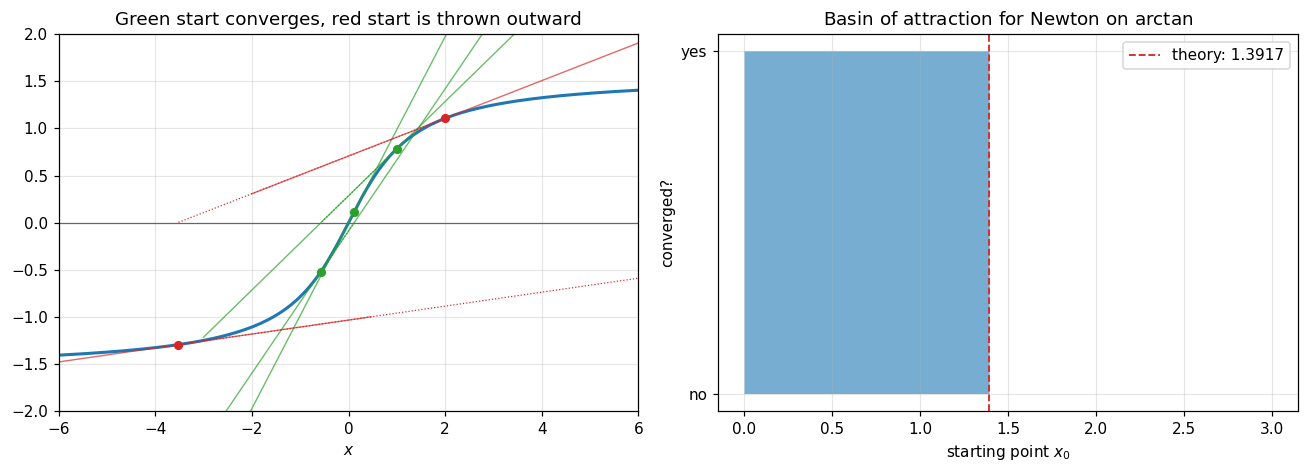

In [7]:
xs_plot = np.linspace(-6, 6, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

ax1.plot(xs_plot, atan(xs_plot), lw=2, label=r"$\arctan x$")
ax1.axhline(0, color="0.4", lw=0.8)
for x0, colour in [(1.0, "C2"), (2.0, "C3")]:
    x = x0
    for _ in range(3):
        t = np.linspace(x - 4, x + 4, 2)
        ax1.plot(t, atan(x) + datan(x) * (t - x), colour, lw=0.9, alpha=0.7)
        ax1.plot([x], [atan(x)], "o", color=colour, ms=5)
        nxt = x - atan(x) / datan(x)
        ax1.plot([x, nxt], [atan(x), 0], colour, ls=":", lw=0.8)
        x = nxt
        if abs(x) > 6:
            break
ax1.set_ylim(-2, 2); ax1.set_xlim(-6, 6)
ax1.set_xlabel("$x$")
ax1.set_title("Green start converges, red start is thrown outward")

with np.errstate(over="ignore", invalid="ignore"):
    starts = np.linspace(0.0, 3.0, 400)
    conv = np.array([R.newton(atan, datan, float(s), max_iter=60).converged
                     for s in starts])
ax2.fill_between(starts, 0, conv.astype(float), step="mid", alpha=0.6)
ax2.axvline(1.3917, color="C3", ls="--", lw=1.2, label="theory: 1.3917")
ax2.set_xlabel("starting point $x_0$")
ax2.set_ylabel("converged?")
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["no", "yes"])
ax2.set_title("Basin of attraction for Newton on $\\arctan$")
ax2.legend()

fig.tight_layout()
plt.show()

**What to take from this.** The basin has a sharp edge, and it is at exactly the predicted
place. Newton gives you no warning as you approach it. Bisection, by contrast, has no basin at
all: it works from any valid bracket.

### Failure 4: multiple roots

This one is different, because Newton still converges. It just stops being quadratic.

At a root of multiplicity $m$, write $f(x) = (x-r)^m h(x)$ with $h(r) \ne 0$. Then a short
calculation gives

$$x_{k+1} - r \;\approx\; \left(1 - \frac{1}{m}\right)(x_k - r).$$

So the convergence is **linear**, with rate $1 - 1/m$. For a double root that is $1/2$, no
better than bisection. For a triple root it is $2/3$, worse than bisection.

In [8]:
# A triple root at x = 1, times a factor that is not itself a power, so that the
# modified method is genuinely quadratic rather than exact in one step.
fm  = lambda x: (x - 1.0)**3 * (x + 2.0)
dfm = lambda x: 3.0 * (x - 1.0)**2 * (x + 2.0) + (x - 1.0)**3

plain = R.newton(fm, dfm, 1.5, tol=1e-13, max_iter=300)
e_plain = np.abs(plain.iterates - 1.0)

rate = cv.linear_rate(e_plain)
print(f"f(x) = (x-1)^3 (x+2), triple root at x = 1\n")
print(f"plain Newton : {plain.n_iter} iterations")
print(f"   measured rate : {rate:.4f}")
print(f"   theory 1 - 1/m : {1 - 1/3:.4f}")
assert abs(rate - 2/3) < 0.01
print("\nlinear, not quadratic, and slower than bisection.")

f(x) = (x-1)^3 (x+2), triple root at x = 1

plain Newton : 71 iterations
   measured rate : 0.6669
   theory 1 - 1/m : 0.6667

linear, not quadratic, and slower than bisection.


**The fix.** If you know the multiplicity, take a bigger step:

$$x_{k+1} = x_k - m\,\frac{f(x_k)}{f'(x_k)}.$$

The factor $m$ exactly compensates for the flattening, and quadratic convergence returns.

In [9]:
mod = R.newton(fm, dfm, 1.5, tol=1e-13, max_iter=300, multiplicity=3)
e_mod = np.abs(mod.iterates - 1.0)
order_mod = cv.observed_order(e_mod)

print(f"modified Newton with m = 3 : {mod.n_iter} iterations")
print(f"   measured order : {float(order_mod[-1]):.4f}   (theory 2)")
print(f"   errors         : {np.array2string(e_mod, precision=2)}")
print(f"\nspeedup: {plain.n_iter} iterations down to {mod.n_iter}.")

assert abs(float(order_mod[-1]) - 2.0) < 0.05
assert mod.n_iter < plain.n_iter / 10

modified Newton with m = 3 : 4 iterations
   measured order : 1.9983   (theory 2)
   errors         : [5.00e-01 2.27e-02 5.68e-05 3.59e-10 0.00e+00]

speedup: 71 iterations down to 4.


If you do **not** know $m$, apply Newton to $u(x) = f(x)/f'(x)$ instead. That function has a
**simple** root wherever $f$ has a root of any multiplicity, so plain Newton on $u$ is
quadratic. The price is needing $f''$.

There is also a warning here that belongs to lesson 06. A multiple root has $f'(r) = 0$, so its
condition number $1/|f'(r)|$ is infinite. Even with the modified method converging quadratically,
the *accuracy* you can reach is limited by the problem, not the algorithm. Lesson 12 measures
exactly how limited.

## 4. The secant method: Newton without the derivative

Newton needs $f'$. Often you do not have it, or it is expensive, or the function is a black box.

Replace the derivative by the slope through the last two points:

$$f'(x_k) \;\approx\; \frac{f(x_k) - f(x_{k-1})}{x_k - x_{k-1}}.$$

Substituting into Newton gives the **secant method**:

$$\boxed{\;x_{k+1} \;=\; x_k - f(x_k)\,\frac{x_k - x_{k-1}}{f(x_k) - f(x_{k-1})}\;}$$

Geometrically: Newton follows the tangent, the secant method follows the line through the last
two points. It needs two starting values and no derivative.

**Write it as an update, not as a formula.** The algebraically identical form
$(x_{k-1}f_k - x_kf_{k-1})/(f_k - f_{k-1})$ subtracts two nearly equal products once the
iterates are close, which is lesson 05. The update form adds a small correction to a good value
and does not.

> **Theorem 11.2 (Secant convergence).** At a simple root, the secant method converges with
> order $p = (1+\sqrt5)/2 \approx 1.618$, the golden ratio.
>
> *Sketch.* The error satisfies $e_{k+1} \approx C\,e_k e_{k-1}$. Assuming
> $e_{k+1} = A e_k^p$ and substituting gives $p^2 = p + 1$, whose positive root is the golden
> ratio. Exercise 2.2 fills in the details.

### Cost: the comparison people get wrong

Newton needs order 2 and two evaluations per step. The secant method needs order 1.618 and
**one**. Per step Newton wins. Per evaluation, which is what actually costs you time:

$$\text{Newton: } 2^{1/2} \approx 1.414 \text{ per evaluation}, \qquad
\text{secant: } 1.618^{1/1} = 1.618 \text{ per evaluation}.$$

**The secant method is more efficient than Newton** whenever $f'$ costs about as much as $f$.

In [10]:
runs = {
    "Newton": R.newton(f, df, 1.0),
    "secant": R.secant(f, 1.0, 2.0),
}

print(f"{'method':>10} {'order':>8} {'iterations':>11} {'f evaluations':>15} "
      f"{'final error':>13}")
print("-" * 62)
for name, res in runs.items():
    e = res.errors(SQRT2)
    o = cv.observed_order(e)
    print(f"{name:>10} {float(o[-1]):>8.4f} {res.n_iter:>11} {res.n_feval:>15} "
          f"{e[-1]:>13.2e}")

n, s = runs["Newton"], runs["secant"]
print(f"\nNewton took fewer iterations ({n.n_iter} against {s.n_iter}),")
print(f"but MORE evaluations ({n.n_feval} against {s.n_feval}).")
print(f"\nefficiency index, order^(1/evals per step):")
print(f"   Newton : 2^(1/2)     = {2**0.5:.4f}")
print(f"   secant : 1.618^(1/1) = {1.618:.4f}")

assert s.n_feval < n.n_feval, "the secant method should use fewer evaluations"
assert abs(float(cv.observed_order(s.errors(SQRT2))[-1]) - 1.618) < 0.05

    method    order  iterations   f evaluations   final error
--------------------------------------------------------------
    Newton   1.9998           6              19      2.22e-16
    secant   1.6075           8               9      0.00e+00

Newton took fewer iterations (6 against 8),
but MORE evaluations (19 against 9).

efficiency index, order^(1/evals per step):
   Newton : 2^(1/2)     = 1.4142
   secant : 1.618^(1/1) = 1.6180


## 5. Muller's method: reaching complex roots

The secant method fits a **line** through two points. Muller fits a **parabola** through three,
and takes the parabola's root nearest the last iterate. Order about 1.84, between the secant
method and Newton.

Its real advantage is elsewhere. A quadratic can have complex roots, so Muller can jump off the
real line and find a **complex root from three real starting points**. No other method in this
lesson can.

In [11]:
# x^2 + x + 1 has no real roots at all.
poly = lambda x: x**2 + x + 1.0
m = R.muller(poly, 0.0, 0.5, 1.0)

print("f(x) = x^2 + x + 1, which has NO real roots\n")
print(f"   Muller found      : {m.root}")
print(f"   |residual|        : {m.residuals[-1]:.3e}")
print(f"   true roots        : {np.roots([1, 1, 1])}")
print(f"   error             : {abs(m.root - np.roots([1,1,1])[0]):.3e}")

assert abs(m.root.imag) > 0.5, "Muller should leave the real line"
assert m.residuals[-1] < 1e-14

print("\nstarting from three REAL points, it found a complex root.")
print("the square root inside the quadratic formula went negative, and")
print("the implementation simply carried on in complex arithmetic.")
print("bisection, secant and Newton on real data can never do this.")

f(x) = x^2 + x + 1, which has NO real roots

   Muller found      : (-0.5+0.8660254037844387j)
   |residual|        : 0.000e+00
   true roots        : [-0.5+0.866025j -0.5-0.866025j]
   error             : 2.220e-16

starting from three REAL points, it found a complex root.
the square root inside the quadratic formula went negative, and
the implementation simply carried on in complex arithmetic.
bisection, secant and Newton on real data can never do this.


The implementation uses the same cancellation-avoiding trick as lesson 05: of the two possible
denominators $b \pm \sqrt{b^2 - 4af}$ it picks the one of **larger** magnitude.

## 6. Third order: Chebyshev and Halley

Keep one more Taylor term than Newton and you get a cubic method. Two standard ones:

$$
\text{Chebyshev:}\quad x_{k+1} = x_k - \frac{f}{f'}\left(1 + \frac{f f''}{2f'^2}\right),
\qquad
\text{Halley:}\quad x_{k+1} = x_k - \frac{2ff'}{2f'^2 - ff''}.
$$

Both are order 3, so correct digits roughly **triple** each step. Both need $f''$, so three
evaluations per step.

In [12]:
fe   = lambda x: np.exp(x) - 2.0        # root at ln 2
dfe  = np.exp
d2fe = np.exp
LN2  = np.log(2.0)

third = {
    "Newton":    R.newton(fe, dfe, 2.0),
    "Chebyshev": R.chebyshev(fe, dfe, d2fe, 2.0),
    "Halley":    R.halley(fe, dfe, d2fe, 2.0),
}

print("f(x) = e^x - 2, root at ln 2, starting from x0 = 2\n")
print(f"{'method':>11} {'order':>8} {'theory':>7} {'iters':>7} {'evals':>7} "
      f"{'error':>12}")
print("-" * 58)
for name, res in third.items():
    e = res.errors(LN2)
    # cv.reliable_order, not observed_order[-1]: a cubic method reaches the roundoff floor
    # in four steps, so the final triple straddles it and reports nonsense. Lesson 07.
    o = cv.reliable_order(e)
    theory = 2 if name == "Newton" else 3
    print(f"{name:>11} {o:>8.4f} {theory:>7} {res.n_iter:>7} "
          f"{res.n_feval:>7} {e[-1]:>12.2e}")
    assert abs(o - theory) < 0.15, f"{name} order mismatch: measured {o}"

print()
print("a note on that measurement. these methods reach machine precision in four")
print("steps, so there are only two or three usable order estimates and the last")
print("one straddles the roundoff floor. cv.reliable_order discards it:")
cheb_e = third["Chebyshev"].errors(LN2)
print(f"   all estimates for Chebyshev : "
      f"{np.round(cv.observed_order(cheb_e), 4)}")
print(f"   reliable_order picks        : {cv.reliable_order(cheb_e):.4f}")
print("   the final 1.97 is noise, not a measurement.")

print("\nboth cubic methods hit order 3, as predicted.")
print("efficiency index, order^(1/evals):")
for name, order, evals in [("Newton", 2, 2), ("Chebyshev", 3, 3), ("Halley", 3, 3)]:
    print(f"   {name:>10}: {order}^(1/{evals}) = {order**(1/evals):.4f}")
print("\nNewton wins on that measure. higher order is not automatically better,")
print("because each extra order costs another derivative.")

f(x) = e^x - 2, root at ln 2, starting from x0 = 2

     method    order  theory   iters   evals        error
----------------------------------------------------------
     Newton   1.9994       2       6      19     0.00e+00
  Chebyshev   2.9396       3       4      17     1.11e-16
     Halley   2.9996       3       4      17     0.00e+00

a note on that measurement. these methods reach machine precision in four
steps, so there are only two or three usable order estimates and the last
one straddles the roundoff floor. cv.reliable_order discards it:
   all estimates for Chebyshev : [2.5513 2.9396 1.9678]
   reliable_order picks        : 2.9396
   the final 1.97 is noise, not a measurement.

both cubic methods hit order 3, as predicted.
efficiency index, order^(1/evals):
       Newton: 2^(1/2) = 1.4142
    Chebyshev: 3^(1/3) = 1.4422
       Halley: 3^(1/3) = 1.4422

Newton wins on that measure. higher order is not automatically better,
because each extra order costs another derivative.

**That last table is the point.** Chebyshev and Halley converge in fewer iterations and are
*less* efficient per evaluation than Newton. Higher order pays only when function evaluations
are cheap relative to the number of iterations you save, which is rare.

## 7. Brent's method: what you should actually use

The lesson so far is a list of trade-offs:

| | Guaranteed | Fast | Needs $f'$ |
|---|---|---|---|
| bisection | yes | no | no |
| Newton | no | yes | yes |
| secant | no | yes | no |

**Brent's method** gets the first two at once. Each step tries inverse quadratic interpolation,
falls back to a secant step, and falls back to **bisection** whenever the interpolated point is
not safely inside the bracket or is not shrinking it fast enough. The bracket is maintained
throughout, so the guarantee holds; the interpolation is used whenever it is safe, so the speed
is nearly that of the secant method.

This is `scipy.optimize.brentq`, and it is the right default whenever you have a bracket and no
derivative.

In [13]:
from scipy.optimize import brentq

suite = [
    ("x^2 - 2",        f,                                    1.0, 2.0, SQRT2),
    ("e^x - 2",        fe,                                   0.0, 2.0, LN2),
    ("x^3 - 2x - 5",   lambda x: x**3 - 2*x - 5,             2.0, 3.0, 2.0945514815423265),
    ("cos x - x",      lambda x: np.cos(x) - x,              0.0, 1.0, 0.7390851332151607),
    ("x^10 - 1",       lambda x: x**10 - 1.0,                0.0, 1.3, 1.0),
]

print(f"{'problem':>14} {'bisect':>7} {'Illinois':>9} {'secant':>7} {'Brent':>6} "
      f"{'scipy':>6}   {'Brent error':>12}")
print("-" * 76)
totals = dict(bisect=0, illinois=0, secant=0, brent=0)
for name, fn, lo, hi, exact in suite:
    b  = R.bisection(fn, lo, hi, tol=1e-14, max_iter=500)
    il = R.illinois(fn, lo, hi, tol=1e-14, max_iter=500)
    sc = R.secant(fn, lo, hi, tol=1e-14, max_iter=500)
    br = R.brent(fn, lo, hi, tol=1e-14, max_iter=500)
    ref = brentq(fn, lo, hi, xtol=1e-15, rtol=8.9e-16)
    totals["bisect"] += b.n_feval
    totals["illinois"] += il.n_feval
    totals["secant"] += sc.n_feval
    totals["brent"] += br.n_feval
    print(f"{name:>14} {b.n_feval:>7} {il.n_feval:>9} {sc.n_feval:>7} {br.n_feval:>6} "
          f"{'-':>6}   {abs(br.root - exact):>12.2e}")
    assert abs(br.root - ref) < 1e-12, f"{name}: our Brent must match scipy"

print(f"\ntotal f evaluations across the suite:")
for k, v in totals.items():
    print(f"   {k:>9}: {v:>4}   ({v/totals['brent']:.1f}x Brent)")
print("\nour Brent agreed with scipy.optimize.brentq to 1e-12 on every problem.")

       problem  bisect  Illinois  secant  Brent  scipy    Brent error
----------------------------------------------------------------------------
       x^2 - 2      49        10       9      9      -       5.33e-15
       e^x - 2      50        11      10     10      -       5.22e-15
  x^3 - 2x - 5      49        10       9      8      -       5.33e-15
     cos x - x      49         9       8      8      -       5.55e-16
      x^10 - 1      49        18       7     10      -       0.00e+00

total f evaluations across the suite:
      bisect:  246   (5.5x Brent)
    illinois:   58   (1.3x Brent)
      secant:   43   (1.0x Brent)
       brent:   45   (1.0x Brent)

our Brent agreed with scipy.optimize.brentq to 1e-12 on every problem.


## 8. Choosing a method

```text
Do you have a bracket?
├── YES
│   ├── Do you have f' and a good guess?
│   │   ├── YES -> Newton, with a bisection fallback
│   │   └── NO  -> BRENT.  the default answer.
│   └── Is f very expensive and you need guaranteed digits? -> bisection
└── NO
    ├── Do you have f'?
    │   ├── YES -> Newton, and safeguard it
    │   └── NO  -> secant, from two nearby points
    ├── Expecting complex roots? -> Muller
    ├── Is it a polynomial? -> lesson 13 has better tools
    └── Is the root multiple? -> modified Newton, or Newton on f/f'
```

| Method | Order | Evals/step | Efficiency | Guaranteed | Needs |
|---|---|---|---|---|---|
| bisection | 1 (rate 1/2) | 1 | 1.000 | **yes** | a bracket |
| Illinois | 1.44 | 1 | 1.440 | **yes** | a bracket |
| secant | 1.618 | 1 | **1.618** | no | two points |
| Brent | 1.84 typical | 1 | 1.840 | **yes** | a bracket |
| Muller | 1.84 | 1 | 1.840 | no | three points, gives complex roots |
| Newton | 2 | 2 | 1.414 | no | $f'$ |
| Chebyshev, Halley | 3 | 3 | 1.442 | no | $f'$ and $f''$ |

Efficiency here is $p^{1/\text{evals}}$, the order achieved per function evaluation. On that
measure the humble secant method beats Newton, and Brent beats everything while still being
unable to fail.

## 9. Complexity

Every method in this lesson costs $O(1)$ memory and a handful of arithmetic operations per
step. **The cost is the function evaluations**, and nothing else, because in a real problem
$f$ might be a simulation that takes minutes.

| Quantity | Newton | Secant |
|---|---|---|
| Evaluations per step | 2 | 1 |
| Steps to go from $10^{-1}$ to $10^{-16}$ | 4 | 6 |
| Total evaluations | 8 | 6 |

To reach a tolerance $\tau$ from an error $e_0$, a method of order $p$ needs about
$\log_p\!\big(\log \tau / \log e_0\big)$ steps. That double logarithm is why the difference
between order 1.6 and order 3 is only a step or two, and why nobody uses order 10 methods.

## 10. Common mistakes

1. **Using Newton without a fallback.** It has four failure modes and gives no warning. Always
   cap the iterations and check the residual.
2. **Comparing methods by iteration count.** Section 4: Newton wins on iterations and loses on
   evaluations.
3. **Not noticing a multiple root.** Newton silently drops to linear. If it is converging
   slowly and steadily, suspect multiplicity and check $f'$ near the root.
4. **Writing the secant step as a ratio of products.** Cancellation, lesson 05. Write it as an
   update.
5. **Assuming higher order is better.** Section 6: Halley converges in fewer steps and is less
   efficient per evaluation than Newton.
6. **Using a finite difference derivative inside Newton.** That is the secant method with extra
   steps, and a badly chosen step size makes it worse than the secant method. Lesson 60
   explains the step size trade-off.
7. **Trusting Newton's step size as an error estimate.** It is a good estimate *when* the
   convergence is quadratic, and useless at a multiple root.

## 11. Exercises

**Level 1, conceptual**

1.1 Newton needs two evaluations per step and the secant method needs one. Explain which is
more efficient and under what assumption.

1.2 Why does Newton converge only linearly at a double root, and what does multiplying the
step by 2 do about it?

1.3 Give a function and a starting point for which Newton cycles forever, and verify it by
hand.

**Level 2, mathematical**

2.1 Complete the proof of Theorem 11.1, being careful about where $f'(x_k) \ne 0$ is used.

2.2 Prove the secant order is the golden ratio. Start from $e_{k+1} \approx C e_k e_{k-1}$,
assume $e_{k+1} = Ae_k^p$, and derive $p^2 = p + 1$.

2.3 For a root of multiplicity $m$, write $f = (x-r)^m h$ and show the Newton iteration
satisfies $e_{k+1} = (1 - 1/m)e_k + O(e_k^2)$.

2.4 Show that $u = f/f'$ has a simple root wherever $f$ has a root of any multiplicity, and
work out what Newton applied to $u$ looks like in terms of $f$, $f'$ and $f''$.

2.5 Derive Halley's method by applying Newton to $f/\sqrt{f'}$.

**Level 3, computational**

3.1 Implement a **safeguarded Newton**: take the Newton step when it stays inside the current
bracket, and bisect otherwise. Verify it never fails on the section 7 test suite.

3.2 Implement Newton for complex $x$ and plot the basin of attraction for $z^3 - 1$, colouring
each starting point by which of the three roots it reaches. The boundary is a fractal.

3.3 Implement Newton on $u = f/f'$ and confirm it is quadratic at the triple root of section 3
without being told the multiplicity.

**Level 4, experimental**

4.1 Measure the efficiency index empirically. For each method, count total evaluations to reach
$10^{-12}$ across a suite of problems, and rank them. Does the ranking match the theoretical
$p^{1/\text{evals}}$?

4.2 For $f(x) = (x-1)^m$ with $m = 1 \dots 6$, measure Newton's convergence rate and confirm it
is $1 - 1/m$ each time.

4.3 Find the exact boundary of Newton's basin for $\arctan$ by bisecting on the starting point.
Compare with the theoretical $1.3917$.

**Level 5, advanced**

5.1 **Kantorovich's theorem** gives conditions on $f$ and $x_0$ alone that *guarantee* Newton
converges, with no reference to the unknown root. State it and verify it numerically on a case
where it applies and one where it does not.

5.2 Newton in the complex plane for $p(z) = z^3 - 1$ produces the Newton fractal. Explain why
the basin boundary must be the same for all three roots, and why that forces it to be
nowhere-smooth.

5.3 The secant method uses the last two points. **Inverse quadratic interpolation** uses the
last three, fitting $x$ as a quadratic in $y$ rather than the other way round. Derive it,
implement it, measure its order (about 1.84), and explain why Brent needs the bisection
safeguard on top of it.

Solutions are in [`solutions/part02_root_finding.md`](../solutions/part02_root_finding.md).

## 12. Key takeaways

- **Newton is the fixed point iteration designed so $g'(r) = 0$.** Everything else follows
  from that one choice.
- At a **simple** root it is quadratic, with asymptotic constant $|f''(r)/2f'(r)|$. Measured
  here: order 1.9998 and the constant correct to five digits.
- It has **four** failure modes: a vanishing derivative, cycling (measured: an exact 2-cycle),
  divergence outside the basin (measured: the edge falls between $x_0 = 1.39$ and $1.40$,
  against a theoretical $1.3917$), and multiple roots.
- At a root of multiplicity $m$ Newton is **linear** with rate $1 - 1/m$. Measured 0.6667 for a
  triple root, against theory 0.6667. Multiplying the step by $m$ restores order 2, measured
  here as 71 iterations down to 4.
- The **secant** method drops the derivative for order 1.618 and one evaluation per step, and is
  therefore **more efficient than Newton per evaluation**, measured at 9 evaluations against 19.
- **Muller** fits a parabola and can therefore find complex roots from real starting points,
  demonstrated on $x^2+x+1$.
- Higher order is not automatically better. Halley is order 3 and less efficient per evaluation
  than Newton, because each extra order costs another derivative.
- **Brent** combines interpolation with a bisection guard: as safe as bisection, nearly as fast
  as the secant method. It matched `scipy.optimize.brentq` to $10^{-12}$ on every test problem
  here, and it is the right default.

## Where this goes next

We now have six methods with six different convergence orders. Lesson 12 puts them side by side
on the same problems, measures every order and every rate against its theory, and then asks the
question none of these methods can answer for itself: **how accurately can this root be found
at all?** That is the conditioning of the root, and the Wilkinson polynomial shows it can be far
worse than anyone expects.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 1.4 (Newton's method, quadratic
convergence, linear convergence at multiple roots) and section 1.5 (secant method and variants,
Brent's method); Gupta, Numerical Methods, sections 3.5 (Newton-Raphson), 3.7 (secant), 3.10
(Muller) and 3.11 (Chebyshev's third order method). Halley's method, the efficiency index, the
basin of attraction experiment and the Kantorovich exercise are supplementary.*